# Tiled read

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
import pathlib
import os
sys.path.append(os.path.abspath(".."))

In [5]:
from src.io import RAW_DIR
from src.config import load_sentinel2_config

In [6]:
root, target = next((root, file) for root, _, files in RAW_DIR.walk() for file in files)

In [14]:
all_band_file = root / target
all_band_file

PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/raw/MAM/S2A_MSIL2A_20220516T110631_N0510_R137_T30STG_20240617T123024_ALLBANDS.tif')

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

When opening a file with rasterio we can get the [tiles size of the raster](https://rasterio.readthedocs.io/en/latest/topics/windowed-rw.html) with `src.block_shapes`. Since we also know that each scene has 5181 rows and 5169 columns, we can compute the number of tiles in each direction, and if there will be some skewed tile. For the column direction:

In [20]:
5169 // 1024, 5169 % 1024

(5, 49)

So, we will have 5 full tiles and 1 tile with only 49 pixels on the column direction. The information about the window block size is controlled with the rasterio Profile properties `blockxsize` and `blockysize`.

In [52]:
5181 // 1024, 5181 % 1024

(5, 61)

In [53]:
with rasterio.open(all_band_file) as src:
    print(type(src))
    green = src.read(1)

<class 'rasterio.io.DatasetReader'>


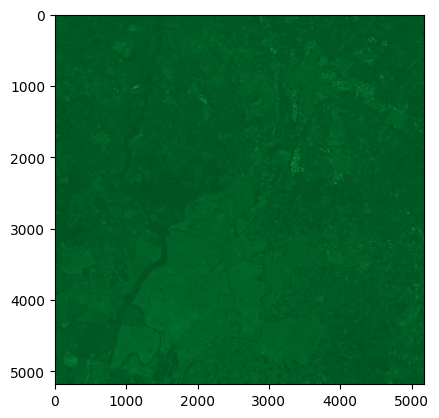

In [32]:
plt.imshow(green, cmap="Greens_r")

size is: (1024, 1024)
(0, 0): Window(col_off=0, row_off=0, width=1024, height=1024)
(0, 1): Window(col_off=1024, row_off=0, width=1024, height=1024)
(0, 2): Window(col_off=2048, row_off=0, width=1024, height=1024)
(0, 3): Window(col_off=3072, row_off=0, width=1024, height=1024)
(0, 4): Window(col_off=4096, row_off=0, width=1024, height=1024)
(0, 5): Window(col_off=5120, row_off=0, width=49, height=1024)
(1, 0): Window(col_off=0, row_off=1024, width=1024, height=1024)
(1, 1): Window(col_off=1024, row_off=1024, width=1024, height=1024)
(1, 2): Window(col_off=2048, row_off=1024, width=1024, height=1024)
(1, 3): Window(col_off=3072, row_off=1024, width=1024, height=1024)
(1, 4): Window(col_off=4096, row_off=1024, width=1024, height=1024)
(1, 5): Window(col_off=5120, row_off=1024, width=49, height=1024)


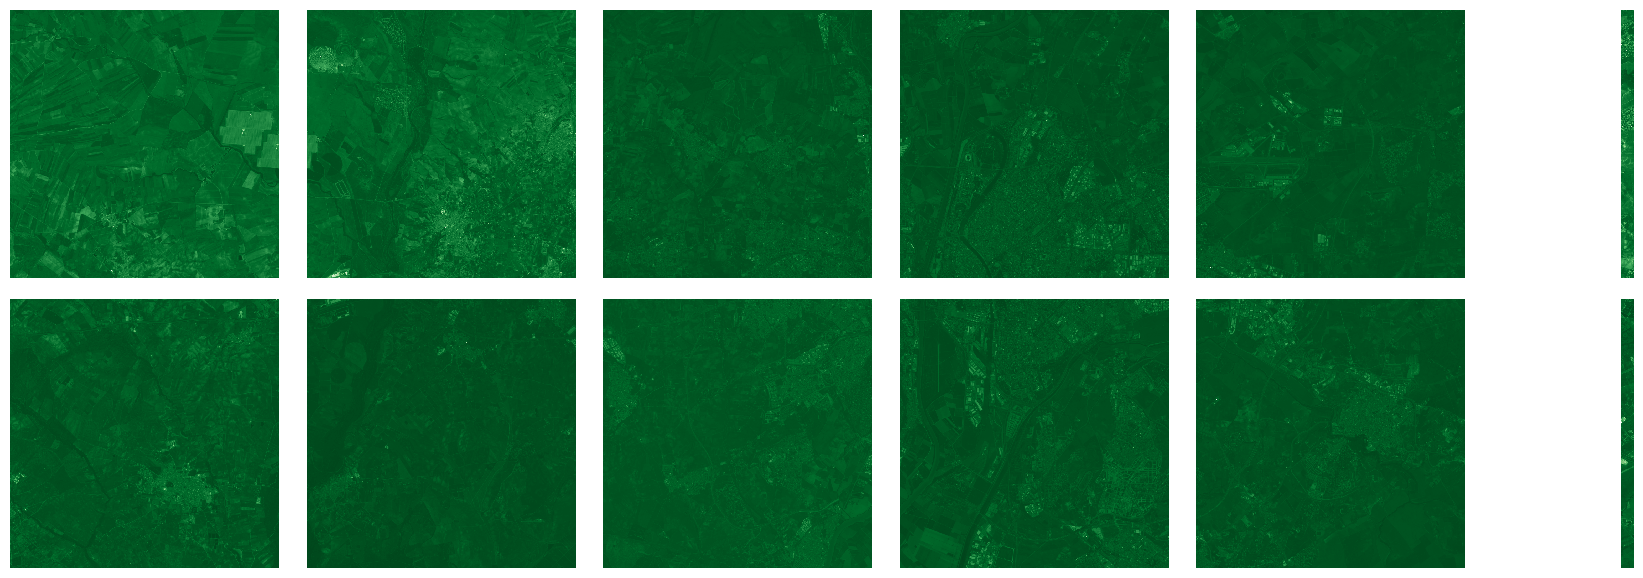

In [57]:
n_tiles = 10
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(18, 6))

row, col = 0, 0
with rasterio.open(all_band_file) as src:
    block_size = src.block_shapes[0]
    print(f"size is: {block_size}")
    
    for ji, window in src.block_windows(1):
        print(f"{ji}: {window}")
        data = src.read(1, window=window)

        if col == 6:
            row += 1
            
        ax[row, col % 6].imshow(data, cmap="Greens_r", interpolation='none')
        ax[row, col % 6].axis('off')
        
        col += 1
        
        if col == 12:
            break
plt.tight_layout(pad=1.5)